In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

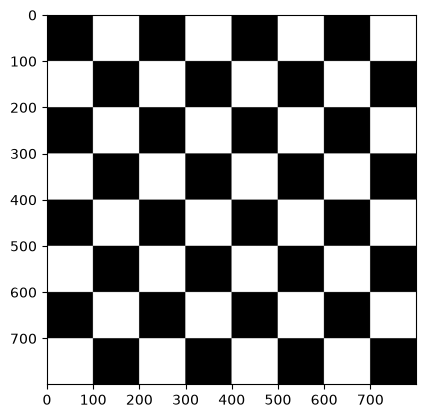

In [5]:
gris_img = np.zeros((800,800,1), dtype = np.uint8)

# Ahora se mostrará como hacer la imagen como la textura de tablero de ajedrez, con cuadrados blancos y negros
for i in range(0, 800, 100):
    for j in range (0, 800, 100):
        if (i//100 + j//100) % 2 != 0:
            gris_img[i:i+100, j:j+100] = 255 #Zona blanca

plt.imshow(gris_img, cmap='gray') #Prueba sin especificar el mapa de color
plt.show()

**TAREA**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

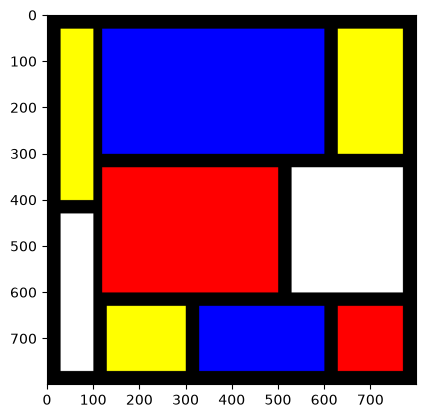

In [7]:

color_img = np.zeros((800,800,3), dtype = np.uint8)

cv2.rectangle(color_img,(30,30),(100,400),(255,255,0),-1)
cv2.rectangle(color_img,(120,30),(600,300),(0,0,255),-1)
cv2.rectangle(color_img,(120,330),(500,600),(255,0,0),-1)
cv2.rectangle(color_img,(30,430),(100,770),(255,255,255),-1)
cv2.rectangle(color_img,(130,630),(300,770),(255,255,0),-1)
cv2.rectangle(color_img,(330,630),(600,770),(0,0,255),-1)
cv2.rectangle(color_img,(530,330),(770,600),(255,255,255),-1)
cv2.rectangle(color_img,(630,30),(770,300),(255,255,0),-1)
cv2.rectangle(color_img,(630,630),(770,770),(255,0,0),-1)


plt.imshow(color_img) 
plt.show()

**TAREA**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.


In [8]:
#Pintando uno por uno con un for forma inicial

while True:      
    ret, frame = vid.read()

    if ret:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        alto, ancho = gray.shape
        
        min_val = 256
        max_val = -1
        min_loc = (0, 0)
        max_loc = (0, 0)
        
        for y in range(alto):
            for x in range(ancho):
                pixel_val = gray[y, x]
                
                if pixel_val < min_val:
                    min_val = pixel_val
                    min_loc = (x, y)
                    
                if pixel_val > max_val:
                    max_val = pixel_val
                    max_loc = (x, y)

        cv2.circle(frame, min_loc, 15, (0, 0, 255), 2)
        cv2.circle(frame, max_loc, 15, (0, 255, 0), 2)

        cv2.imshow('Cam', frame)
    
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\becha\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\interactiveshell.py", line 3823, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\becha\AppData\Local\Temp\ipykernel_1244\3702448698.py", line None, in <module>
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\becha\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\interactiveshell.py", line 2279, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\becha\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\ultratb.py", line 1300, in structured_traceback
    return FormattedTB.structured_traceback(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\becha\anaconda3\envs\VC_P1\Lib\site-packages\IPython\core\ultratb.py", line 1166, in structured_traceback
    retur

In [9]:
#Forma mejorada con ayuda de la IA

vid = cv2.VideoCapture(0, cv2.CAP_DSHOW)

while True:      
    ret, frame = vid.read()

    if ret:
       #Convertimos el fotograma a escala de grises.
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        #Usamos la función optimizada de OpenCV para encontrar los extremos.
        min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(gray)

        #Dibujamos los círculos usando las coordenadas encontradas

        #Oscuro
        cv2.circle(frame, min_loc, 15, (0, 0, 255), 2)

        #Claro
        cv2.circle(frame, max_loc, 15, (0, 255, 0), 2)
        
        # Mostramos el frame
        cv2.imshow('Buscador de brillo', frame)
    
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

**Conversación:**

Pregunta:

Estoy haciendo una práctica de la asignatura de visión por computador de la ULPGC y me han pedido realizar una tarea la cuál pide pintar un círculo en el píxel más claro y en el píxel más oscuro del fotograma.

Lo he realizado, el problema es que la cámara va a saltos, entiendo que hay forma de mejorarlo. ¿Puedes guiarme a mejorar mi código para que funcione la cámara de forma fluida?

while True:      
    ret, frame = vid.read()

    if ret:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        alto, ancho = gray.shape
        
        min_val = 256
        max_val = -1
        min_loc = (0, 0)
        max_loc = (0, 0)
        
        for y in range(alto):
            for x in range(ancho):
                pixel_val = gray[y, x]
                
                if pixel_val < min_val:
                    min_val = pixel_val
                    min_loc = (x, y)
                    
                if pixel_val > max_val:
                    max_val = pixel_val
                    max_loc = (x, y)

        cv2.circle(frame, min_loc, 15, (0, 0, 255), 2)
        cv2.circle(frame, max_loc, 15, (0, 255, 0), 2)

        cv2.imshow('Cam', frame)
    
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()


Respuesta:

El problema de que la cámara vaya a saltos (bajos FPS) se debe a los bucles for anidados. En Python, recorrer cada píxel de una imagen uno a uno es un proceso computacionalmente muy lento. Si tu cámara tiene una resolución de 640x480, estás realizando 307.200 comprobaciones en cada fotograma, lo que satura el procesador y crea ese "lag".

Para procesar imágenes en tiempo real con fluidez, debes aprovechar las funciones nativas de OpenCV. Estas funciones están escritas en C/C++ por debajo y operan de forma "vectorizada", procesando toda la matriz de la imagen casi instantáneamente.

OpenCV tiene una función diseñada exactamente para lo que necesitas: cv2.minMaxLoc(). Esta función analiza toda la imagen de golpe y devuelve los valores mínimos/máximos y sus coordenadas.

**TAREA:** Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.

In [ ]:
# Abrimos la cámara
vid = cv2.VideoCapture(0)

# Dimensiones de la cámara reducidas a la mitad
w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH)/2)
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT)/2)

# Se define el tamaño de las celdas
ncells = 10
off = int(ncells/2)

while True:
    # Leemos un fotograma de la cámara
    ret, frameIN = vid.read()

    if ret:
        # Reducimos el fotograma para que el lienzo sea más pequeño
        frame = cv2.resize(frameIN, (w,h), cv2.INTER_NEAREST)

        # Reducimos la imagen para trabajar con menos píxeles
        down_frame = cv2.resize(frame, (int(w/ncells),int(h/ncells)), cv2.INTER_NEAREST)
        h2, w2, c2 = down_frame.shape

        # Creamos una imagen conjunta de cuatro ventanas
        collage = np.zeros((h2*ncells*2,w2*ncells*2,3), dtype = np.uint8)
        tl = collage[0:h2*ncells,0:w2*ncells]
        tr = collage[0:h2*ncells,w2*ncells:w2*ncells*2]
        bl = collage[h2*ncells:h2*ncells*2,0:w2*ncells]
        br = collage[h2*ncells:h2*ncells*2,w2*ncells:w2*ncells*2]

        # Recorremos los píxeles de la imagen reducida
        for y in range(0,h2):
            for x in range(0,w2):
                # Separamos los colores del píxel
                r = down_frame[y,x,0]
                g = down_frame[y,x,1]
                b = down_frame[y,x,2]

                # La intensidad define el radio del círculo
                rad = int((int(r) + int(g) + int(b))/(ncells*3*2))
                pos = (x*ncells+off,y*ncells+off)

                # Dibujamos cuatro versiones con colores diferentes
                cv2.circle(tl,pos,rad,(int(b),int(g),int(r)),-1)
                cv2.circle(tr,pos,rad,(255-int(r),int(g),int(b)),-1)
                cv2.circle(bl,pos,rad,(int(r),255-int(b),int(g)),-1)
                cv2.circle(br,pos,rad,(int(b),int(g),255-int(r)),-1)

        # Mostramos el collage pop art
        cv2.imshow('Pop art', collage)

    # Pulsamos ESC para terminar
    if cv2.waitKey(20) == 27:
        break

# Liberamos la cámara
vid.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

: 